In [19]:
# Import Libraries
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Matplotlib configurations
plt.rc('axes', labelsize=14)
plt.rc('xtick', labelsize=12)
plt.rc('ytick', labelsize=12)

# Helper function to fix color for OpenCV images
def fixColor(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


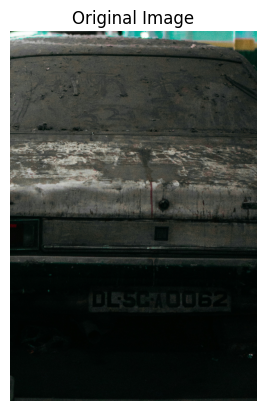

In [20]:
# Load the image
image = cv2.imread('/kaggle/input/cropped-license-plate/Croppedprateek-katyal-NHE252Af6kA-unsplash.jpg')

# Display the original image
plt.imshow(fixColor(image))
plt.title('Original Image')
plt.axis('off')
plt.show()


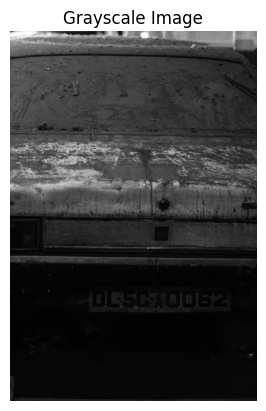

In [21]:
# Convert the image to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Display the grayscale image
plt.imshow(gray, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')
plt.show()


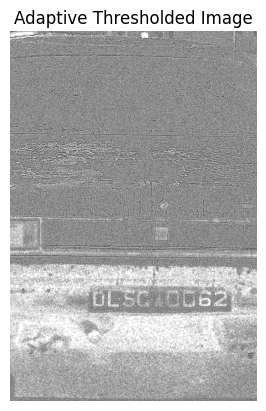

In [22]:
# Apply adaptive thresholding
th2 = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                            cv2.THRESH_BINARY, 11, 2)

# Display the thresholded image
plt.imshow(th2, cmap='gray')
plt.title('Adaptive Thresholded Image')
plt.axis('off')
plt.show()


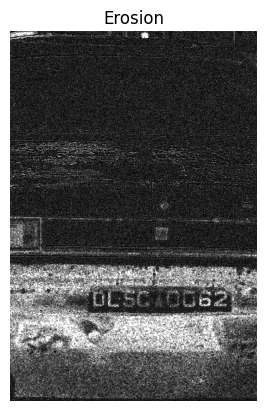

In [23]:
# Define a kernel for morphological operations
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))

# Apply erosion to remove noise
eroded = cv2.erode(th2, kernel, iterations=1)

# Display the result of Erosion
plt.imshow(eroded, cmap='gray')
plt.title('Erosion')
plt.axis('off')
plt.show()

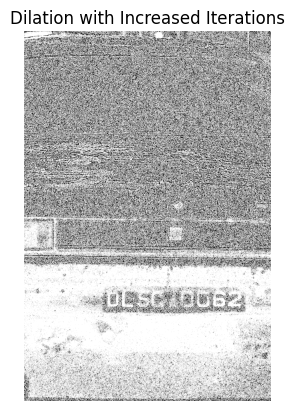

In [24]:
# Apply dilation to enhance the text
dilated = cv2.dilate(eroded, kernel, iterations=2)

# Display the result of dilation
plt.imshow(dilated, cmap='gray')
plt.title('Dilation with Increased Iterations')
plt.axis('off')
plt.show()


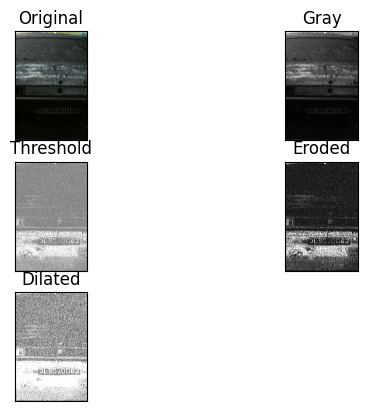

In [25]:
# Create a list of processed images and their titles
images = [image, gray, th2, eroded, dilated]
titles = ['Original', 'Gray', 'Threshold', 'Eroded', 'Dilated']

# Plot all images in a grid
for i in range(5):
    plt.subplot(3, 2, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])
plt.show()
